# Experiment 1.3.5 - Continuous SNN local features vs fixed-duration count + Linear

## Scientific question

Can a continuously running short-timescale SNN transform precise spike timing into more discriminative local temporal features than direct fixed-duration channel-wise spike counts?

### Baseline

\[
X_{1:T} -> \text{250 ms input count} -> C[N_{bin},30] -> \text{flatten} -> \text{Linear} -> y
\]

### SNN model

\[
X_{1:T} -> \text{continuous 3-layer SNN} -> S^{out}_{1:T} -> \text{250 ms output count} -> Z[N_{bin},D] -> \text{flatten} -> \text{Linear} -> y
\]

The SNN state is **not reset at 250 ms boundaries**. Synaptic and membrane states evolve continuously over the full padded observation window. The 250 ms bins are used only to read out local SNN features.

This is **not** `fixed_250ms_ce`: there is no per-bin class loss. There is one whole-segment cross-entropy loss after the global Linear head.

In [12]:
from __future__ import annotations
from pathlib import Path
import copy, hashlib, json, math, os, random, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import snntorch as snn
from snntorch import surrogate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from IPython.display import display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate writingRing repository root")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from snn.accel_reconstruction_eval.datasets import load_acceleration_data

print("Repository root:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Repository root: /home/ted/project/writingRing
PyTorch: 2.11.0+cu128
CUDA available: True


## 1. Configuration

In [13]:
ACTION0_DIR = REPO_ROOT / "outputs/action0_wavelets_0e5_1_2_4_8_sr_64"
ACTION1_DIR = REPO_ROOT / "outputs/action1_wavelets_0e5_1_2_4_8_sr_64"
DATASET_ROOTS = [
    ACTION0_DIR / "low-pass/aligned-board-events/segmentation_padded",
    ACTION1_DIR / "low-pass/aligned-board-events/segmentation_padded",
]

EXPECTED_EVENT_REPRESENTATION = "unsigned"
EXPECTED_EVENT_FEATURE_SCHEMA = "custom_wavelet_polarity_split_abs_events_v1"
EVENT_CHANNEL_COUNT = 30
TOTAL_CHANNEL_COUNT = 36
EXPECTED_SAMPLING_RATE_HZ = 64.0
INCLUDED_LABELS = ("A","B","C","D","E","X","G","H","I","J","K","L")

SPLIT_SEED = 12345
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
SEEDS = (11, 23, 101)

FIXED_BIN_MS = 250.0

# Configurable 3-layer local feature SNN: 30 -> H1 -> H2 -> D
SNN_LAYER_WIDTHS = (128, 128, 64)
SNN_LAYER_SHIFTS = ((2, 3), (2, 3), (2,))

TAU_MEM_MS = 22.54
THRESHOLD = 0.5
SURROGATE_SLOPE = 25.0
RESET_MECHANISM = "subtract"

BATCH_SIZE = 64
NUM_WORKERS = 0
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.0
GRAD_CLIP_NORM = None
LOGREG_MAX_ITER = 5000

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EXPERIMENT_ID = "experiment_1_3_5_continuous_snn_local_features"
RESULTS_DIR = REPO_ROOT / "notebooks/artifacts" / EXPERIMENT_ID
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESUME_EXISTING = True
SAVE_CHECKPOINTS = True

IMPULSE_DIAGNOSTIC_MS = 750.0
DECAY_FRACTION = 0.01

print("Experiment:", EXPERIMENT_ID)
print("Device:", DEVICE)
print("Split seed:", SPLIT_SEED)
print("Training seeds:", SEEDS)
print("SNN widths:", SNN_LAYER_WIDTHS)
print("SNN shifts:", SNN_LAYER_SHIFTS)

Experiment: experiment_1_3_5_continuous_snn_local_features
Device: cuda
Split seed: 12345
Training seeds: (11, 23, 101)
SNN widths: (128, 128, 64)
SNN shifts: ((2, 3), (2, 3), (2,))


## 2. Reproducibility and shift/tau helpers

In [14]:
def derive_seed(master_seed: int, *parts: object) -> int:
    text = "|".join([str(master_seed), *(str(p) for p in parts)])
    return int.from_bytes(hashlib.sha256(text.encode()).digest()[:4], "little")


def seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try: torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError: torch.use_deterministic_algorithms(True)


def worker_init_fn(worker_id: int):
    s = torch.initial_seed() % (2**32)
    random.seed(s); np.random.seed(s)


def shift_to_alpha(shift: int) -> float:
    return float(1.0 - 2.0 ** (-int(shift)))


def alpha_to_tau_ms(alpha: float, fs: float) -> float:
    return float(-(1000.0 / fs) / math.log(alpha))


def allocate_neurons(width: int, shifts: tuple[int, ...]) -> tuple[int, ...]:
    base, remainder = divmod(width, len(shifts))
    counts = [base] * len(shifts)
    order = []
    left, right = 0, len(shifts) - 1
    while left <= right:
        order.append(left)
        if left != right: order.append(right)
        left += 1; right -= 1
    for i in range(remainder): counts[order[i]] += 1
    return tuple(counts)


def alpha_vector(width: int, shifts: tuple[int, ...]) -> torch.Tensor:
    vals = []
    for shift, n in zip(shifts, allocate_neurons(width, shifts), strict=True):
        vals.extend([shift_to_alpha(shift)] * n)
    return torch.tensor(vals, dtype=torch.float32)

seed_everything(2026)

## 3. Load and validate unsigned event data

In [15]:
data = load_acceleration_data(DATASET_ROOTS, repository_root=REPO_ROOT, require_reconstruction=False)
rates = {float(m.sampling_rate_hz) for m in data.producer_metadatas}
if len(rates) != 1: raise ValueError(rates)
SAMPLING_RATE_HZ = rates.pop()
if not np.isclose(SAMPLING_RATE_HZ, EXPECTED_SAMPLING_RATE_HZ):
    raise ValueError((SAMPLING_RATE_HZ, EXPECTED_SAMPLING_RATE_HZ))

for root, meta in zip(data.padded_roots, data.producer_metadatas, strict=True):
    raw = meta.raw
    if raw.get("event_representation") != EXPECTED_EVENT_REPRESENTATION: raise ValueError(root)
    if raw.get("event_feature_schema") != EXPECTED_EVENT_FEATURE_SCHEMA: raise ValueError(root)
    if raw.get("event_channel_count") != EVENT_CHANNEL_COUNT: raise ValueError(root)
    if meta.channel_count != TOTAL_CHANNEL_COUNT: raise ValueError(root)

rows = []
keep = set(INCLUDED_LABELS)
for pi, p in enumerate(data.packages):
    ev = np.asarray(p.padded_spike_imu[..., :EVENT_CHANNEL_COUNT])
    if np.any(~np.isfinite(ev)) or np.any(ev < 0): raise ValueError("Invalid unsigned events")
    for si, label in enumerate(p.labels.astype(str)):
        if label not in keep: continue
        rows.append(dict(
            package_index=pi, segment_index=si, user=str(p.user), action=str(p.action), label=str(label),
            valid_length=int(p.valid_lengths[si]), package_padded_length=int(p.padded_spike_imu.shape[1]),
            sample_id=f"{p.user}/action_{p.action}/{si}",
        ))

manifest = pd.DataFrame(rows)
labels_sorted = sorted(manifest.label.unique().tolist())
CLASS_TO_IDX = {lab:i for i,lab in enumerate(labels_sorted)}
IDX_TO_CLASS = {i:lab for lab,i in CLASS_TO_IDX.items()}
manifest["label_idx"] = manifest.label.map(CLASS_TO_IDX).astype(int)
N_CLASSES = len(labels_sorted)
GLOBAL_PADDED_LENGTH = int(manifest.package_padded_length.max())
BIN_SAMPLES = max(1, int(np.rint(FIXED_BIN_MS * SAMPLING_RATE_HZ / 1000.0)))
ACTUAL_BIN_MS = 1000.0 * BIN_SAMPLES / SAMPLING_RATE_HZ
N_READOUT_BINS = int(math.ceil(GLOBAL_PADDED_LENGTH / BIN_SAMPLES))
PADDED_READOUT_LENGTH = N_READOUT_BINS * BIN_SAMPLES

print(f"samples={len(manifest)}, users={manifest.user.nunique()}, classes={N_CLASSES}")
print("labels:", labels_sorted)
print("sampling rate:", SAMPLING_RATE_HZ)
print("global padded length:", GLOBAL_PADDED_LENGTH)
print(f"readout: {BIN_SAMPLES} samples = {ACTUAL_BIN_MS:.3f} ms, bins={N_READOUT_BINS}")
display(manifest.head())

samples=853, users=20, classes=12
labels: ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'J', 'K', 'L', 'X']
sampling rate: 64.0
global padded length: 256
readout: 16 samples = 250.000 ms, bins=16


,package_index,segment_index,user,action,label,valid_length,package_padded_length,sample_id,label_idx
0,0,24,user_0,0,J,72,256,user_0/action_0/24,8
1,0,25,user_0,0,B,128,256,user_0/action_0/25,1
2,0,26,user_0,0,X,106,256,user_0/action_0/26,11
3,0,27,user_0,0,E,122,256,user_0/action_0/27,4
4,0,31,user_0,0,G,124,256,user_0/action_0/31,5


## 4. Padding check, fixed user split, and tensors

In [16]:
def check_zero_padding(tol=1e-12):
    bad = []
    for r in manifest.itertuples(index=False):
        p = data.packages[int(r.package_index)]
        tail = np.asarray(p.padded_spike_imu[int(r.segment_index), int(r.valid_length):, :EVENT_CHANNEL_COUNT])
        mx = float(np.max(np.abs(tail))) if tail.size else 0.0
        if mx > tol: bad.append((r.sample_id, mx))
    if bad: raise ValueError(f"Nonzero padding: {bad[:5]}")
    print("Padding contract verified.")


def make_user_split(seed):
    users = np.asarray(sorted(manifest.user.unique()), dtype=object)
    rng = np.random.default_rng(derive_seed(seed, "user_split")); rng.shuffle(users)
    n = len(users); ntr = int(round(TRAIN_FRACTION*n)); nva = int(round(VAL_FRACTION*n))
    tr, va, te = set(users[:ntr]), set(users[ntr:ntr+nva]), set(users[ntr+nva:])
    assert not (tr & va or tr & te or va & te)
    part = lambda u: manifest[manifest.user.isin(u)].reset_index(drop=True)
    return part(tr), part(va), part(te), dict(train_users=sorted(tr), val_users=sorted(va), test_users=sorted(te))


def build_events(df):
    out = np.zeros((len(df), PADDED_READOUT_LENGTH, EVENT_CHANNEL_COUNT), np.float32)
    for j, r in enumerate(df.itertuples(index=False)):
        p = data.packages[int(r.package_index)]
        x = np.asarray(p.padded_spike_imu[int(r.segment_index), :, :EVENT_CHANNEL_COUNT], np.float32)
        L = min(len(x), PADDED_READOUT_LENGTH)
        out[j, :L] = x[:L]
    return out

check_zero_padding()
train_df, val_df, test_df, split_info = make_user_split(SPLIT_SEED)
X_train, X_val, X_test = map(build_events, (train_df, val_df, test_df))
y_train = train_df.label_idx.to_numpy(np.int64)
y_val = val_df.label_idx.to_numpy(np.int64)
y_test = test_df.label_idx.to_numpy(np.int64)

split_table = pd.DataFrame([
    dict(split="train", n_samples=len(train_df), n_users=train_df.user.nunique(), users=",".join(split_info["train_users"])),
    dict(split="val", n_samples=len(val_df), n_users=val_df.user.nunique(), users=",".join(split_info["val_users"])),
    dict(split="test", n_samples=len(test_df), n_users=test_df.user.nunique(), users=",".join(split_info["test_users"])),
])
display(split_table)
print("train/val/test:", X_train.shape, X_val.shape, X_test.shape)

Padding contract verified.


,split,n_samples,n_users,users
0,train,632,14,"user_0,user_1,user_11,user_12,user_14,user_19,..."
1,val,126,3,"user_15,user_16,user_20"
2,test,95,3,"user_10,user_13,user_18"


train/val/test: (632, 256, 30) (126, 256, 30) (95, 256, 30)


## 5. Baseline: 250 ms input count + Linear

For each fixed interval, the 30 input channels are summed over time. The ordered count matrix is flattened and classified by logistic regression, matching the strong 1.3.x count+Linear baseline.

In [17]:
def input_count_features(X):
    n, T, c = X.shape
    assert T == PADDED_READOUT_LENGTH
    return X.reshape(n, N_READOUT_BINS, BIN_SAMPLES, c).sum(axis=2).astype(np.float32)


def metrics(y, p):
    return dict(
        accuracy=float(accuracy_score(y, p)),
        balanced_accuracy=float(balanced_accuracy_score(y, p)),
        macro_f1=float(f1_score(y, p, average="macro")),
    )

Ctr = input_count_features(X_train).reshape(len(X_train), -1)
Cva = input_count_features(X_val).reshape(len(X_val), -1)
Cte = input_count_features(X_test).reshape(len(X_test), -1)
scaler = StandardScaler().fit(Ctr)
Ctr_s, Cva_s, Cte_s = scaler.transform(Ctr), scaler.transform(Cva), scaler.transform(Cte)
count_linear = LogisticRegression(max_iter=LOGREG_MAX_ITER, solver="lbfgs", random_state=derive_seed(SPLIT_SEED, "count_linear"))
count_linear.fit(Ctr_s, y_train)
COUNT_EVAL = dict(
    train=metrics(y_train, count_linear.predict(Ctr_s)),
    val=metrics(y_val, count_linear.predict(Cva_s)),
    test=metrics(y_test, count_linear.predict(Cte_s)),
    feature_shape=(N_READOUT_BINS, EVENT_CHANNEL_COUNT),
)
COUNT_EVAL

{'train': {'accuracy': 1.0, 'balanced_accuracy': 1.0, 'macro_f1': 1.0},
 'val': {'accuracy': 0.7142857142857143,
  'balanced_accuracy': 0.7077050264550264,
  'macro_f1': 0.7066720517807474},
 'test': {'accuracy': 0.5473684210526316,
  'balanced_accuracy': 0.5562169312169313,
  'macro_f1': 0.548820612365504},
 'feature_shape': (16, 30)}

## 6. Configured SNN time scales

In [18]:
rows = []
for li, (width, shifts) in enumerate(zip(SNN_LAYER_WIDTHS, SNN_LAYER_SHIFTS, strict=True), 1):
    for shift, n in zip(shifts, allocate_neurons(width, shifts), strict=True):
        alpha = shift_to_alpha(shift)
        tau = alpha_to_tau_ms(alpha, SAMPLING_RATE_HZ)
        rows.append(dict(layer=li, width=width, shift=shift, neurons=n, alpha=alpha, tau_syn_ms=tau,
                         residual_after_250ms=math.exp(-ACTUAL_BIN_MS/tau)))
TAU_TABLE = pd.DataFrame(rows)
display(TAU_TABLE)
BETA = float(math.exp(-(1000.0 / SAMPLING_RATE_HZ) / TAU_MEM_MS))
print(f"tau_mem={TAU_MEM_MS:.2f} ms -> beta={BETA:.6f}")
print("Whole-network effective memory is measured later; it is not assumed from one tau_syn.")

,layer,width,shift,neurons,alpha,tau_syn_ms,residual_after_250ms
0,1,128,2,64,0.750,54.313430,0.010023
1,1,128,3,64,0.875,117.013683,0.118067
2,2,128,2,64,0.750,54.313430,0.010023
3,2,128,3,64,0.875,117.013683,0.118067
4,3,64,2,64,0.750,54.313430,0.010023


tau_mem=22.54 ms -> beta=0.499968
Whole-network effective memory is measured later; it is not assumed from one tau_syn.


## 7. Continuous 3-layer SNN + 250 ms output count + Linear

Default architecture:

\[
30 -> 128 -> 128 -> 64
\]

All three Synaptic-LIF layers run continuously for the full segment. The third layer is a learned feature layer, not a 12-class output layer. Every 250 ms, its spikes are counted to form one local feature vector. SNN state continues across the readout boundary.

In [19]:
class ContinuousFeatureSNN(nn.Module):
    def __init__(self):
        super().__init__()
        h1, h2, d = SNN_LAYER_WIDTHS
        spike_grad = surrogate.fast_sigmoid(slope=SURROGATE_SLOPE)
        self.fc1 = nn.Linear(EVENT_CHANNEL_COUNT, h1, bias=False)
        self.lif1 = snn.Synaptic(alpha=alpha_vector(h1, SNN_LAYER_SHIFTS[0]), beta=BETA,
                                 threshold=THRESHOLD, spike_grad=spike_grad, reset_mechanism=RESET_MECHANISM)
        self.fc2 = nn.Linear(h1, h2, bias=False)
        self.lif2 = snn.Synaptic(alpha=alpha_vector(h2, SNN_LAYER_SHIFTS[1]), beta=BETA,
                                 threshold=THRESHOLD, spike_grad=spike_grad, reset_mechanism=RESET_MECHANISM)
        self.fc3 = nn.Linear(h2, d, bias=False)
        self.lif3 = snn.Synaptic(alpha=alpha_vector(d, SNN_LAYER_SHIFTS[2]), beta=BETA,
                                 threshold=THRESHOLD, spike_grad=spike_grad, reset_mechanism=RESET_MECHANISM)
        self.classifier = nn.Linear(N_READOUT_BINS * d, N_CLASSES, bias=True)

    def forward(self, x, diagnostics=False):
        B, T, C = x.shape
        h1, h2, d = SNN_LAYER_WIDTHS
        assert C == EVENT_CHANNEL_COUNT and T == PADDED_READOUT_LENGTH
        syn1 = torch.zeros(B, h1, device=x.device, dtype=x.dtype); mem1 = torch.zeros_like(syn1)
        syn2 = torch.zeros(B, h2, device=x.device, dtype=x.dtype); mem2 = torch.zeros_like(syn2)
        syn3 = torch.zeros(B, d,  device=x.device, dtype=x.dtype); mem3 = torch.zeros_like(syn3)
        acc = torch.zeros(B, d, device=x.device, dtype=x.dtype)
        features = []
        if diagnostics: spk_sum = torch.zeros(3, device=x.device)

        for t in range(T):
            s1, syn1, mem1 = self.lif1(self.fc1(x[:, t]), syn1, mem1)
            s2, syn2, mem2 = self.lif2(self.fc2(s1), syn2, mem2)
            s3, syn3, mem3 = self.lif3(self.fc3(s2), syn3, mem3)
            acc = acc + s3
            if diagnostics:
                spk_sum[0] += s1.detach().sum(); spk_sum[1] += s2.detach().sum(); spk_sum[2] += s3.detach().sum()
            if (t + 1) % BIN_SAMPLES == 0:
                features.append(acc)
                acc = torch.zeros_like(acc)
                # No state reset here.

        Z = torch.stack(features, dim=1)
        logits = self.classifier(Z.flatten(1))
        if not diagnostics: return logits
        den = torch.tensor([h1, h2, d], device=x.device, dtype=x.dtype) * (B*T)
        return logits, dict(features=Z, firing_rates=spk_sum/den)


def make_model(): return ContinuousFeatureSNN()

probe = make_model()
print(probe)
print("parameters:", sum(p.numel() for p in probe.parameters()))
print("local feature shape:", (N_READOUT_BINS, SNN_LAYER_WIDTHS[-1]))
print("global Linear input dim:", N_READOUT_BINS * SNN_LAYER_WIDTHS[-1])

ContinuousFeatureSNN(
  (fc1): Linear(in_features=30, out_features=128, bias=False)
  (lif1): Synaptic()
  (fc2): Linear(in_features=128, out_features=128, bias=False)
  (lif2): Synaptic()
  (fc3): Linear(in_features=128, out_features=64, bias=False)
  (lif3): Synaptic()
  (classifier): Linear(in_features=1024, out_features=12, bias=True)
)
parameters: 40716
local feature shape: (16, 64)
global Linear input dim: 1024


## 8. Zero-input silence and training helpers

In [20]:
@torch.no_grad()
def zero_input_test(model):
    model = model.to(DEVICE).eval()
    x = torch.zeros(2, PADDED_READOUT_LENGTH, EVENT_CHANNEL_COUNT, device=DEVICE)
    logits, d = model(x, diagnostics=True)
    return dict(max_abs_logit=float(logits.abs().max().cpu()),
                l1_fr=float(d["firing_rates"][0].cpu()), l2_fr=float(d["firing_rates"][1].cpu()), l3_fr=float(d["firing_rates"][2].cpu()))

print("zero-input:", zero_input_test(make_model()))


def make_loaders(seed):
    ds = [TensorDataset(torch.from_numpy(X), torch.from_numpy(y)) for X,y in [(X_train,y_train),(X_val,y_val),(X_test,y_test)]]
    g = torch.Generator().manual_seed(derive_seed(seed, "loader"))
    tr = DataLoader(ds[0], batch_size=BATCH_SIZE, shuffle=True, generator=g, num_workers=NUM_WORKERS,
                    worker_init_fn=worker_init_fn if NUM_WORKERS else None, pin_memory=torch.cuda.is_available())
    kw = dict(batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
              worker_init_fn=worker_init_fn if NUM_WORKERS else None, pin_memory=torch.cuda.is_available())
    return tr, DataLoader(ds[1], **kw), DataLoader(ds[2], **kw)


def run_loader(model, loader, criterion, optimizer=None):
    train = optimizer is not None; model.train(train)
    losses=[]; ys=[]; ps=[]; fr=np.zeros(3); n=0
    for xb,yb in loader:
        xb=xb.to(DEVICE, non_blocking=True); yb=yb.to(DEVICE, non_blocking=True)
        if train: optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train):
            logits,d = model(xb, diagnostics=True); loss=criterion(logits,yb)
            if train:
                loss.backward()
                if GRAD_CLIP_NORM is not None: torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                optimizer.step()
        p=logits.argmax(1); b=len(yb)
        losses.append(float(loss.detach().cpu())*b); ys.append(yb.cpu().numpy()); ps.append(p.cpu().numpy())
        fr += d["firing_rates"].detach().cpu().numpy()*b; n += b
    y=np.concatenate(ys); p=np.concatenate(ps); m=metrics(y,p); m["loss"]=sum(losses)/len(y)
    m.update(l1_fr=float(fr[0]/n), l2_fr=float(fr[1]/n), l3_fr=float(fr[2]/n))
    return m


def config_signature():
    return dict(experiment_id=EXPERIMENT_ID, fs=SAMPLING_RATE_HZ, bin_samples=BIN_SAMPLES,
                widths=tuple(SNN_LAYER_WIDTHS), shifts=tuple(tuple(x) for x in SNN_LAYER_SHIFTS),
                tau_mem_ms=TAU_MEM_MS, threshold=THRESHOLD, split_seed=SPLIT_SEED)


def ckpt_path(seed): return RESULTS_DIR / f"snn_seed_{seed}.pt"

zero-input: {'max_abs_logit': 0.030448544770479202, 'l1_fr': 0.0, 'l2_fr': 0.0, 'l3_fr': 0.0}


## 9. Train 3 SNN seeds; select checkpoint by validation BA

In [21]:
def train_seed(seed):
    path = ckpt_path(seed)
    if RESUME_EXISTING and path.exists():
        payload = torch.load(path, map_location="cpu")
        if payload.get("config") != config_signature(): raise ValueError(f"Stale checkpoint: {path}")
        print("loaded", path)
        return payload

    seed_everything(seed)
    tr,va,te = make_loaders(seed)
    model = make_model().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    best_state=None; best_epoch=None; best_ba=-1; best_loss=float("inf"); hist=[]

    for epoch in range(1, NUM_EPOCHS+1):
        tm = run_loader(model,tr,criterion,opt)
        with torch.no_grad(): vm = run_loader(model,va,criterion)
        hist.append(dict(seed=seed, epoch=epoch, **{f"train_{k}":v for k,v in tm.items()}, **{f"val_{k}":v for k,v in vm.items()}))
        improved = vm["balanced_accuracy"] > best_ba or (np.isclose(vm["balanced_accuracy"], best_ba) and vm["loss"] < best_loss)
        if improved:
            best_ba=vm["balanced_accuracy"]; best_loss=vm["loss"]; best_epoch=epoch
            best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        if epoch==1 or epoch%10==0:
            print(f"seed {seed} epoch {epoch:3d} | train loss={tm['loss']:.4f} BA={tm['balanced_accuracy']:.4f} | val loss={vm['loss']:.4f} BA={vm['balanced_accuracy']:.4f} | FR=({vm['l1_fr']:.4f},{vm['l2_fr']:.4f},{vm['l3_fr']:.4f})")

    model.load_state_dict(best_state); model.to(DEVICE)
    with torch.no_grad():
        fm_tr=run_loader(model,tr,criterion); fm_va=run_loader(model,va,criterion); fm_te=run_loader(model,te,criterion)
    payload=dict(config=config_signature(), seed=seed, best_epoch=best_epoch, history=hist,
                 train=fm_tr, val=fm_va, test=fm_te, model_state_dict={k:v.detach().cpu().clone() for k,v in model.state_dict().items()})
    if SAVE_CHECKPOINTS: torch.save(payload,path)
    return payload

runs=[]
for seed in SEEDS:
    print("="*100); print("MASTER SEED",seed)
    runs.append(train_seed(seed))

MASTER SEED 11
seed 11 epoch   1 | train loss=2.4871 BA=0.0836 | val loss=2.4843 BA=0.0833 | FR=(0.0001,0.0000,0.0000)
seed 11 epoch  10 | train loss=1.9383 BA=0.3139 | val loss=2.4464 BA=0.1634 | FR=(0.0007,0.0016,0.0040)
seed 11 epoch  20 | train loss=0.8404 BA=0.7213 | val loss=2.5665 BA=0.4309 | FR=(0.0020,0.0102,0.0275)
seed 11 epoch  30 | train loss=0.4810 BA=0.8446 | val loss=2.4815 BA=0.4670 | FR=(0.0027,0.0170,0.0445)
seed 11 epoch  40 | train loss=0.3090 BA=0.9006 | val loss=2.9161 BA=0.4846 | FR=(0.0032,0.0206,0.0527)
seed 11 epoch  50 | train loss=0.2083 BA=0.9424 | val loss=2.7997 BA=0.5733 | FR=(0.0036,0.0241,0.0593)
seed 11 epoch  60 | train loss=0.1318 BA=0.9635 | val loss=3.3015 BA=0.5358 | FR=(0.0041,0.0290,0.0720)
seed 11 epoch  70 | train loss=0.0876 BA=0.9819 | val loss=3.2087 BA=0.5791 | FR=(0.0044,0.0325,0.0786)
seed 11 epoch  80 | train loss=0.0677 BA=0.9833 | val loss=3.1335 BA=0.6095 | FR=(0.0046,0.0342,0.0806)
seed 11 epoch  90 | train loss=0.0586 BA=0.9833 |

## 10. Results and validation curves

,model,seed,best_epoch,train_accuracy,train_balanced_accuracy,train_macro_f1,val_accuracy,val_balanced_accuracy,val_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1
0,count_250ms_plus_linear,NaN,NaN,1.000000,1.000000,1.000000,0.714286,0.707705,0.706672,0.547368,0.556217,0.548821
1,continuous_snn_plus_linear,11.0,94.0,0.985759,0.986360,0.986664,0.634921,0.626819,0.622948,0.473684,0.477017,0.461864
2,continuous_snn_plus_linear,23.0,86.0,0.987342,0.987741,0.988166,0.626984,0.641567,0.616386,0.452632,0.481481,0.451740
3,continuous_snn_plus_linear,101.0,80.0,0.968354,0.969616,0.969428,0.658730,0.657937,0.643929,0.431579,0.451389,0.435343


,model,n_runs,mean_test_BA,sd_test_BA
0,count_250ms_plus_linear,1,0.556217,NaN
1,continuous_snn_plus_linear,3,0.469963,0.016239


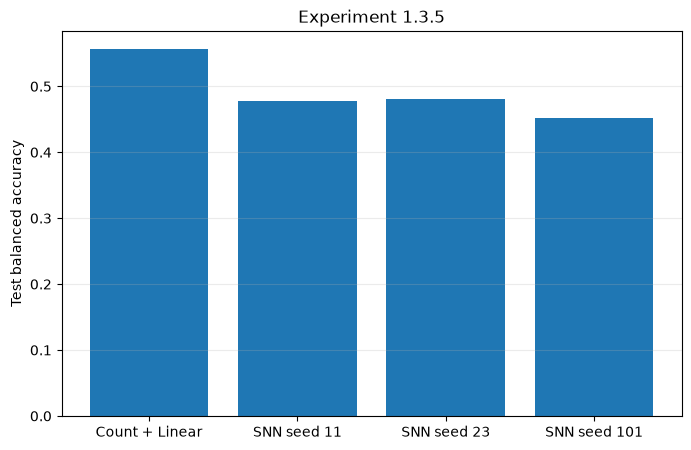

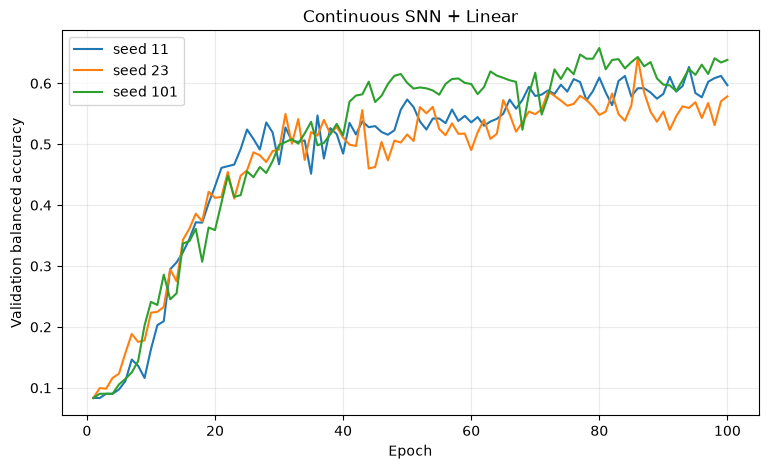

In [22]:
rows=[dict(model="count_250ms_plus_linear", seed=np.nan, best_epoch=np.nan,
           train_accuracy=COUNT_EVAL["train"]["accuracy"], train_balanced_accuracy=COUNT_EVAL["train"]["balanced_accuracy"], train_macro_f1=COUNT_EVAL["train"]["macro_f1"],
           val_accuracy=COUNT_EVAL["val"]["accuracy"], val_balanced_accuracy=COUNT_EVAL["val"]["balanced_accuracy"], val_macro_f1=COUNT_EVAL["val"]["macro_f1"],
           test_accuracy=COUNT_EVAL["test"]["accuracy"], test_balanced_accuracy=COUNT_EVAL["test"]["balanced_accuracy"], test_macro_f1=COUNT_EVAL["test"]["macro_f1"])]
for r in runs:
    rows.append(dict(model="continuous_snn_plus_linear", seed=r["seed"], best_epoch=r["best_epoch"],
                     train_accuracy=r["train"]["accuracy"], train_balanced_accuracy=r["train"]["balanced_accuracy"], train_macro_f1=r["train"]["macro_f1"],
                     val_accuracy=r["val"]["accuracy"], val_balanced_accuracy=r["val"]["balanced_accuracy"], val_macro_f1=r["val"]["macro_f1"],
                     test_accuracy=r["test"]["accuracy"], test_balanced_accuracy=r["test"]["balanced_accuracy"], test_macro_f1=r["test"]["macro_f1"]))
RESULTS = pd.DataFrame(rows); display(RESULTS)
snnr=RESULTS[RESULTS.model=="continuous_snn_plus_linear"]
SUMMARY=pd.DataFrame([
    dict(model="count_250ms_plus_linear", n_runs=1, mean_test_BA=COUNT_EVAL["test"]["balanced_accuracy"], sd_test_BA=np.nan),
    dict(model="continuous_snn_plus_linear", n_runs=len(snnr), mean_test_BA=snnr.test_balanced_accuracy.mean(), sd_test_BA=snnr.test_balanced_accuracy.std(ddof=1)),
]); display(SUMMARY)
RESULTS.to_csv(RESULTS_DIR/"results.csv",index=False); SUMMARY.to_csv(RESULTS_DIR/"summary.csv",index=False)

plt.figure(figsize=(8,5))
labels=["Count + Linear"]+[f"SNN seed {int(x)}" for x in snnr.seed]
vals=[COUNT_EVAL["test"]["balanced_accuracy"]]+snnr.test_balanced_accuracy.tolist()
plt.bar(range(len(vals)),vals); plt.xticks(range(len(vals)),labels); plt.ylabel("Test balanced accuracy")
plt.title("Experiment 1.3.5"); plt.grid(axis="y",alpha=.25); plt.show()

plt.figure(figsize=(9,5))
for r in runs:
    h=pd.DataFrame(r["history"]); plt.plot(h.epoch,h.val_balanced_accuracy,label=f"seed {r['seed']}")
plt.xlabel("Epoch"); plt.ylabel("Validation balanced accuracy"); plt.title("Continuous SNN + Linear"); plt.grid(alpha=.25); plt.legend(); plt.show()

## 11. Effective-memory / impulse-response diagnostic

best seed: 101
normalized state envelope near 250.0 ms: 0.11109993782973812


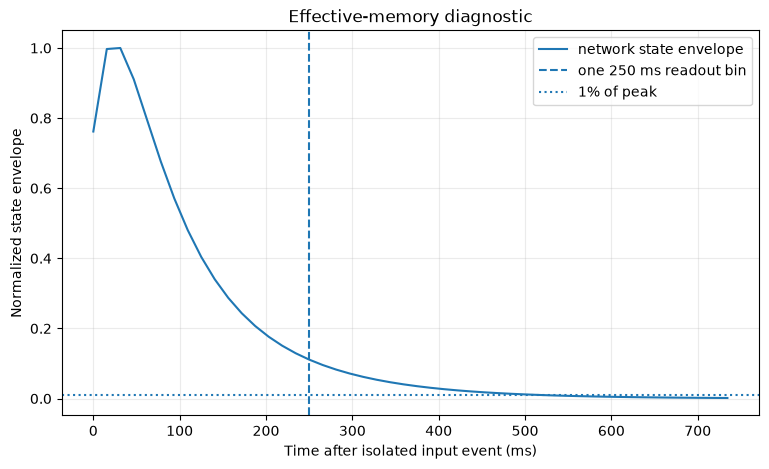

In [23]:
@torch.no_grad()
def impulse_trace(model, duration_ms=IMPULSE_DIAGNOSTIC_MS, input_channel=0, amplitude=1.0):
    model=model.to(DEVICE).eval(); steps=int(math.ceil(duration_ms*SAMPLING_RATE_HZ/1000.0))
    h1,h2,d=SNN_LAYER_WIDTHS
    syn1=torch.zeros(1,h1,device=DEVICE); mem1=torch.zeros_like(syn1)
    syn2=torch.zeros(1,h2,device=DEVICE); mem2=torch.zeros_like(syn2)
    syn3=torch.zeros(1,d,device=DEVICE); mem3=torch.zeros_like(syn3)
    rows=[]
    for t in range(steps):
        x=torch.zeros(1,EVENT_CHANNEL_COUNT,device=DEVICE)
        if t==0: x[0,input_channel]=amplitude
        s1,syn1,mem1=model.lif1(model.fc1(x),syn1,mem1)
        s2,syn2,mem2=model.lif2(model.fc2(s1),syn2,mem2)
        s3,syn3,mem3=model.lif3(model.fc3(s2),syn3,mem3)
        vals=[syn1.abs().mean(),mem1.abs().mean(),syn2.abs().mean(),mem2.abs().mean(),syn3.abs().mean(),mem3.abs().mean()]
        rows.append(dict(step=t,time_ms=1000*t/SAMPLING_RATE_HZ,state_envelope=float(torch.stack(vals).max().cpu()),
                         l1_spikes=float(s1.sum().cpu()),l2_spikes=float(s2.sum().cpu()),l3_spikes=float(s3.sum().cpu())))
    df=pd.DataFrame(rows); peak=df.state_envelope.max(); df["normalized_state_envelope"]=df.state_envelope/peak if peak>0 else 0.0
    return df

best_run=max(runs,key=lambda r:r["val"]["balanced_accuracy"])
best_model=make_model(); best_model.load_state_dict(best_run["model_state_dict"]); best_model.to(DEVICE)
TRACE=impulse_trace(best_model)
idx=int(np.argmin(np.abs(TRACE.time_ms.to_numpy()-ACTUAL_BIN_MS)))
print("best seed:",best_run["seed"])
print(f"normalized state envelope near {ACTUAL_BIN_MS:.1f} ms:",float(TRACE.iloc[idx].normalized_state_envelope))

plt.figure(figsize=(9,5)); plt.plot(TRACE.time_ms,TRACE.normalized_state_envelope,label="network state envelope")
plt.axvline(ACTUAL_BIN_MS,linestyle="--",label="one 250 ms readout bin"); plt.axhline(DECAY_FRACTION,linestyle=":",label=f"{DECAY_FRACTION:.0%} of peak")
plt.xlabel("Time after isolated input event (ms)"); plt.ylabel("Normalized state envelope"); plt.title("Effective-memory diagnostic")
plt.grid(alpha=.25); plt.legend(); plt.show()
TRACE.to_csv(RESULTS_DIR/"impulse_response_best_model.csv",index=False)

## 12. Interpretation

The primary comparison is:

\[
\boxed{\text{250 ms input Count + Linear} \quad \text{vs} \quad \text{Continuous short-tau SNN + 250 ms output Count + Linear}}
\]

- If SNN + Linear is better, continuous temporal processing before coarse aggregation adds task-relevant information beyond direct input count.
- If the two are similar, the 250 ms count representation may already capture most of the useful local information accessible to this SNN.
- If SNN + Linear is worse, first inspect firing regime, optimization stability, feature width, and the effective-memory diagnostic before concluding that precise spike timing is uninformative.
- The 250 ms boundaries are output readout boundaries only. They are not SNN reset boundaries.
- The third SNN layer is a local feature layer, not a per-bin letter classifier.